In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
import joblib

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

In [5]:
selected_features = [
    'mean radius',
    'mean texture',
    'mean perimeter',
    'mean area',
    'mean smoothness',
    'mean compactness',
    'worst radius',
    'worst texture',
    'worst perimeter',
    'worst area'
]

X = X[selected_features]
y = data.target
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

X.head()

Features Shape: (569, 10)
Target Shape: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,worst radius,worst texture,worst perimeter,worst area
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,25.38,17.33,184.60,2019.0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,24.99,23.41,158.80,1956.0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,23.57,25.53,152.50,1709.0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,14.91,26.50,98.87,567.7
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,22.54,16.67,152.20,1575.0


In [6]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:

# Scale
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
# Train model
model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [12]:
y_pred_log = model.predict(X_test)
y_prob_log = model.predict_proba(X_test)[:,1]
accuracy_log = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", accuracy_log)

Logistic Regression Accuracy: 0.9298245614035088


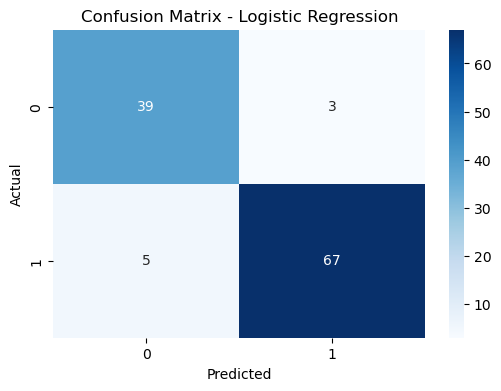

In [13]:
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [14]:
# Save
joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully")

Model Saved Successfully
